## 1. Setup & configuration
All tunable choices live in one cell so they are easy to change and to document in the report.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ---- Paths ---------------------------------------------------------------
# Raw CMS file: the first path that exists is used. Or set it yourself, e.g. RAW_CSV = r"C:\path\to\file.csv"
RAW_CSV_CANDIDATES = [
    "data/raw/mpos24.csv",
    "data/raw/Medicare_Physician_Other_Practitioners_by_Provider_and_Service_2024.csv",
    "Medicare_Physician_Other_Practitioners_by_Provider_and_Service_2024.csv",
]
RAW_CSV  = next((p for p in RAW_CSV_CANDIDATES if os.path.exists(p)), None)
ML_TABLE = "data/processed/ml_table.parquet"       # optional: only used to check row_id alignment
OUT_PARQUET   = "data/processed/peer_features.parquet"
OUT_DICT      = "data/processed/peer_features_dictionary.csv"
FIG_DIR       = "figures"

# ---- Choices (each one is justified in the notebook) ---------------------
MIN_GROUP = 20            # min rows in a peer group before we trust its statistics (chosen in Section 4)
DEV_SAMPLE_FRAC = None    # e.g. 0.1 = keep 10% of providers for quick tests; None = full data
SEED = 42

# Peer groups: fine group first, coarser fallback second
PEER_FINE   = ["Rndrng_Prvdr_Type", "Place_Of_Srvc", "HCPCS_Cd", "segment"]
PEER_COARSE = ["Rndrng_Prvdr_Type", "Place_Of_Srvc", "segment"]

# Metrics compared against peers.
# Avg_Mdcr_Stdzd_Amt is used instead of Pymt/Alowd: those three are ~0.98-0.99 correlated,
# so the team keeps only one money column.
METRICS = ["Tot_Srvcs", "Avg_Sbmtd_Chrg", "Avg_Mdcr_Stdzd_Amt", "srvcs_per_bene", "chrg_to_alowd"]

if DEV_SAMPLE_FRAC:   # never overwrite the real outputs with sampled ones
    OUT_PARQUET = OUT_PARQUET.replace(".parquet", "_DEV.parquet")
    OUT_DICT    = OUT_DICT.replace(".csv", "_DEV.csv")

os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 2. Load the raw CMS data


In [2]:
assert RAW_CSV, ("Raw CSV not found. Put it at data/raw/mpos24.csv or set RAW_CSV in the config cell "
                 "to the full path of the CMS 'by Provider and Service' 2024 file.")

usecols = ["Rndrng_NPI", "Rndrng_Prvdr_Type", "Rndrng_Prvdr_Ent_Cd", "Rndrng_Prvdr_RUCA", "Rndrng_Prvdr_Cntry",
           "HCPCS_Cd", "HCPCS_Desc", "HCPCS_Drug_Ind", "Place_Of_Srvc",
           "Tot_Benes", "Tot_Srvcs", "Tot_Bene_Day_Srvcs",
           "Avg_Sbmtd_Chrg", "Avg_Mdcr_Alowd_Amt", "Avg_Mdcr_Stdzd_Amt"]
cat_cols = ["Rndrng_Prvdr_Type", "Rndrng_Prvdr_Ent_Cd", "Rndrng_Prvdr_RUCA", "Rndrng_Prvdr_Cntry",
            "HCPCS_Cd", "HCPCS_Desc", "HCPCS_Drug_Ind", "Place_Of_Srvc"]

raw = pd.read_csv(RAW_CSV, usecols=usecols, dtype={c: "category" for c in cat_cols})
print(f"Loaded {RAW_CSV}: {raw.shape[0]:,} rows x {raw.shape[1]} columns | {raw.memory_usage(deep=True).sum()/1e9:.2f} GB")
raw.head()

Loaded Medicare_Physician_Other_Practitioners_by_Provider_and_Service_2024.csv: 9,781,673 rows x 15 columns | 0.65 GB


,Rndrng_NPI,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_Cntry,Rndrng_Prvdr_Type,HCPCS_Cd,HCPCS_Desc,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Stdzd_Amt
0,1003000126,I,1,US,Internal Medicine,99221,Initial hospital care with straightforward or ...,N,F,36,36.0,36,284.378889,79.063889,62.376389
1,1003000126,I,1,US,Internal Medicine,99222,Initial hospital care with straightforward or ...,N,F,150,150.0,150,352.176333,126.340800,96.007133
2,1003000126,I,1,US,Internal Medicine,99223,Initial hospital care with moderate level of m...,N,F,63,63.0,63,783.997302,170.360000,131.999365
3,1003000126,I,1,US,Internal Medicine,99231,Subsequent hospital care with straightforward ...,N,F,11,16.0,16,122.125000,47.832500,33.706250
4,1003000126,I,1,US,Internal Medicine,99232,Subsequent hospital care with moderate levelof...,N,F,37,70.0,70,583.606857,81.428571,58.486857


## 3. Clean
1. **Keep U.S. providers only** (foreign addresses are outside the peer benchmarks).
2. **Drop impossible rows:** services < beneficiaries, beneficiary-days > services, or a $0 allowed amount.
3. **Create `segment`:** `Tot_Srvcs` is a count of visits for regular services, of billing units for drugs, and of **miles** for transport codes, so these must never be compared with each other. `segment` is `drug` (Part B drug indicator), `mileage` (transport-mileage codes) or `service`.
4. **RUCA:** the few missing rural–urban codes become an explicit `unknown` category.
5. **`row_id`** = position after cleaning (same convention as the team's `ml_table`).
6. Compute the two ratio features, then drop the columns that are no longer needed.

In [3]:
n_raw = len(raw)
is_us = raw["Rndrng_Prvdr_Cntry"] == "US"
impossible = ((raw["Tot_Srvcs"] < raw["Tot_Benes"]) |
              (raw["Tot_Bene_Day_Srvcs"] > raw["Tot_Srvcs"]) |
              (raw["Avg_Mdcr_Alowd_Amt"] <= 0))
n_foreign    = int((~is_us).sum())
n_impossible = int((is_us & impossible).sum())

df = raw[is_us & ~impossible].reset_index(drop=True)      # boolean filter returns a new frame: no extra .copy()
del raw

df["row_id"] = np.arange(len(df), dtype="int64")

# segment: unit of Tot_Srvcs. The mileage regex runs on the ~thousands of distinct descriptions, not on 9.78M rows.
is_drug = df["HCPCS_Drug_Ind"] == "Y"
desc_cats = pd.Series(df["HCPCS_Desc"].cat.categories)
mileage_desc = desc_cats[desc_cats.str.contains("mileage|per statute mile|miles actually travel", case=False, na=False)]
is_mileage = df["HCPCS_Desc"].isin(mileage_desc)
df["segment"] = pd.Categorical(np.select([is_drug, is_mileage], ["drug", "mileage"], default="service"))

# RUCA: explicit "unknown" instead of NaN
df["Rndrng_Prvdr_RUCA"] = df["Rndrng_Prvdr_RUCA"].cat.add_categories("unknown").fillna("unknown")

# Ratio features
df["srvcs_per_bene"] = df["Tot_Srvcs"] / df["Tot_Benes"]           # service intensity per beneficiary
df["chrg_to_alowd"]  = df["Avg_Sbmtd_Chrg"] / df["Avg_Mdcr_Alowd_Amt"]   # submitted charge relative to allowed amount

df = df.drop(columns=["Rndrng_Prvdr_Cntry", "HCPCS_Desc", "HCPCS_Drug_Ind", "Tot_Bene_Day_Srvcs", "Avg_Mdcr_Alowd_Amt"])
for c in df.select_dtypes("category"):
    df[c] = df[c].cat.remove_unused_categories()                   # e.g. the foreign-country codes

cleaning_log = pd.DataFrame({
    "rows": [n_raw, -n_foreign, -n_impossible, len(df)],
}, index=["raw file", "foreign providers removed", "impossible values / $0 allowed removed", "kept"])
cleaning_log["pct_of_raw"] = (cleaning_log["rows"] / n_raw * 100).round(4)
display(cleaning_log)
print("Segments:"); display(df["segment"].value_counts())
print("RUCA set to unknown:", int((df["Rndrng_Prvdr_RUCA"] == "unknown").sum()))

,rows,pct_of_raw
raw file,9781673,100.0000
foreign providers removed,-422,-0.0043
impossible values / $0 allowed removed,-90,-0.0009
kept,9781161,99.9948


Segments:


segment
service    9241898
drug        529570
mileage       9693
Name: count, dtype: int64

RUCA set to unknown: 4984


- Cleaning removes only `512` of `978163` rows (`0.0052%`): `422` foreign providers and `90` impossible rows — the CMS extract is already very clean
- Segments: `[service]` / `[drug]` / `[mileage]` rows. For reference, the team's cleaning gave 9,242,364 / 529,613 / 9,696 — these should match

In [13]:
# Check that row_id lines up with the team's ml_table (same rows in the same order)
if os.path.exists(ML_TABLE) and not DEV_SAMPLE_FRAC:
    ref = pd.read_parquet(ML_TABLE, columns=["row_id", "Rndrng_NPI", "HCPCS_Cd", "Place_Of_Srvc"])
    aligned = (len(ref) == len(df)
               and bool((ref["row_id"].to_numpy() == df["row_id"].to_numpy()).all())
               and all((ref[c].astype(str).to_numpy() == df[c].astype(str).to_numpy()).all()
                       for c in ["Rndrng_NPI", "HCPCS_Cd", "Place_Of_Srvc"]))
    print("row_id alignment with the team's ml_table:",
          "OK - tables will join directly on row_id" if aligned else
          "MISMATCH - different CSV version or cleaning rules; do NOT join on row_id until resolved")
    del ref
else:
    print("ml_table.parquet not found (or DEV mode) - skipping the row_id alignment check")

ml_table.parquet not found (or DEV mode) - skipping the row_id alignment check


In [14]:
# Optional dev mode: keep a random subset of PROVIDERS (whole providers, so their rows stay together)
if DEV_SAMPLE_FRAC:
    keep = df["Rndrng_NPI"].drop_duplicates().sample(frac=DEV_SAMPLE_FRAC, random_state=SEED)
    df = df[df["Rndrng_NPI"].isin(keep)].reset_index(drop=True)

# Peer-key columns must be categorical (fast groupby) and complete
for c in PEER_FINE:
    if df[c].dtype != "category":
        df[c] = df[c].astype("category")
assert df[PEER_FINE].isna().sum().sum() == 0, "Null values in peer-group columns"
assert df["row_id"].is_unique

print(f"Rows: {len(df):,} | Providers: {df['Rndrng_NPI'].nunique():,} | Memory: {df.memory_usage(deep=True).sum()/1e9:.2f} GB")
df.head()

Rows: 9,781,161 | Providers: 1,207,397 | Memory: 1.45 GB


,Rndrng_NPI,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_Type,HCPCS_Cd,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Stdzd_Amt,...,Avg_Sbmtd_Chrg_pct,Avg_Mdcr_Stdzd_Amt_z,Avg_Mdcr_Stdzd_Amt_rz,Avg_Mdcr_Stdzd_Amt_pct,srvcs_per_bene_z,srvcs_per_bene_rz,srvcs_per_bene_pct,chrg_to_alowd_z,chrg_to_alowd_rz,chrg_to_alowd_pct
0,1003000126,I,1,Internal Medicine,99221,F,36,36.0,284.378889,62.376389,...,0.668590,0.143389,-0.542469,0.374279,-0.327584,0.000000,0.322341,0.361351,0.511449,0.691674
1,1003000126,I,1,Internal Medicine,99222,F,150,150.0,352.176333,96.007133,...,0.533899,-0.322542,-0.984816,0.256103,-0.441683,0.000000,0.288144,-0.029090,0.083648,0.540169
2,1003000126,I,1,Internal Medicine,99223,F,63,63.0,783.997302,131.999365,...,0.798393,0.337839,-0.014812,0.495303,-0.533128,-0.452678,0.211388,0.694092,0.939493,0.795612
3,1003000126,I,1,Internal Medicine,99231,F,11,16.0,122.125000,33.706250,...,0.581724,-3.213474,-7.673257,0.018777,-0.619074,-0.489222,0.282278,0.130456,0.233453,0.606760
4,1003000126,I,1,Internal Medicine,99232,F,37,70.0,583.606857,58.486857,...,0.985425,-1.328188,-2.960593,0.070345,-0.442682,-0.402662,0.336296,2.361741,2.673457,0.982533


## 4. Quantify the peer groups
A z-score is only meaningful if the group it is computed in is big enough. The proposal names badly defined peer groups as a key risk, so before computing any feature we measure the groups.

- **Fine group:** `Specialty × Place of Service × HCPCS × segment` (most comparable, but many groups will be small)
- **Coarse fallback:** `Specialty × Place of Service × segment` (much larger groups, less comparable)

`ngroup()` gives every group an integer id, which makes the later per-group statistics fast.

In [15]:
df["gid_fine"]   = df.groupby(PEER_FINE,   observed=True, sort=False).ngroup().astype("int32")
df["gid_coarse"] = df.groupby(PEER_COARSE, observed=True, sort=False).ngroup().astype("int32")

df["group_n"]        = df.groupby("gid_fine")["row_id"].transform("size").astype("int32")
df["group_n_coarse"] = df.groupby("gid_coarse")["row_id"].transform("size").astype("int32")

fine_sizes   = df.groupby("gid_fine").size()
coarse_sizes = df.groupby("gid_coarse").size()
print(f"Fine groups:   {len(fine_sizes):>9,} | singletons: {(fine_sizes == 1).sum():,} | median size: {fine_sizes.median():.0f}")
print(f"Coarse groups: {len(coarse_sizes):>9,} | median size: {coarse_sizes.median():.0f}")

cutoffs = [2, 5, 10, 20, 30, 50, 100]
coverage = pd.DataFrame({
    "groups_smaller":     [(fine_sizes < c).sum() for c in cutoffs],
    "pct_groups_smaller": [(fine_sizes < c).mean() * 100 for c in cutoffs],
    "rows_in_them":       [(df["group_n"] < c).sum() for c in cutoffs],
    "pct_rows_in_them":   [(df["group_n"] < c).mean() * 100 for c in cutoffs],
}, index=pd.Index(cutoffs, name="group size <")).round(2)
coverage

Fine groups:      59,777 | singletons: 18,987 | median size: 3
Coarse groups:       344 | median size: 1258


,groups_smaller,pct_groups_smaller,rows_in_them,pct_rows_in_them
group size <,,,,
2,18987,31.76,18987,0.19
5,32847,54.95,56089,0.57
10,39749,66.50,101741,1.04
20,44953,75.20,173146,1.77
30,47398,79.29,231844,2.37
50,49969,83.59,330102,3.37
100,52812,88.35,531990,5.44


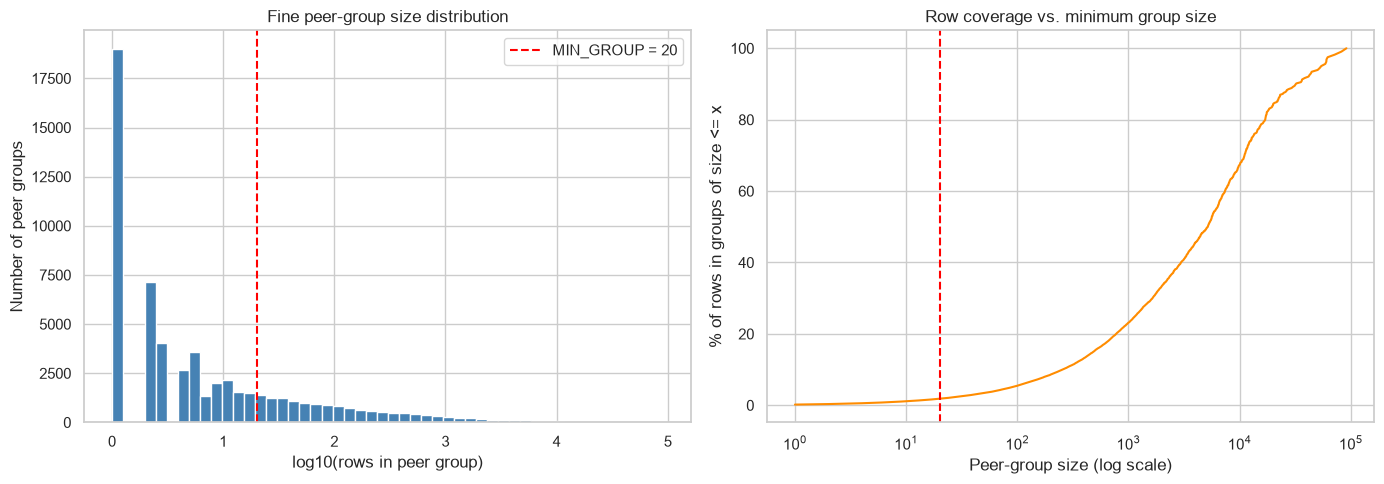

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: how many groups are of each size
axes[0].hist(np.log10(fine_sizes), bins=50, color="steelblue")
axes[0].axvline(np.log10(MIN_GROUP), color="red", ls="--", label=f"MIN_GROUP = {MIN_GROUP}")
axes[0].set_xlabel("log10(rows in peer group)")
axes[0].set_ylabel("Number of peer groups")
axes[0].set_title("Fine peer-group size distribution")
axes[0].legend()

# Right: what share of ROWS sits in groups of size <= x
vc = fine_sizes.value_counts().sort_index()              # group size -> number of groups of that size
rows_at_size = vc * vc.index                             # rows sitting in groups of that size
cum_share = rows_at_size.cumsum() / rows_at_size.sum() * 100
axes[1].plot(vc.index, cum_share.values, color="darkorange")
axes[1].axvline(MIN_GROUP, color="red", ls="--")
axes[1].set_xscale("log")
axes[1].set_xlabel("Peer-group size (log scale)")
axes[1].set_ylabel("% of rows in groups of size <= x")
axes[1].set_title("Row coverage vs. minimum group size")

savefig("peer_group_sizes")

## 5. Build the peer features (with fallback)
For each metric, each row gets three numbers measuring how far it sits from its peers:

| Feature | Meaning |
|---|---|
| `<metric>_z` | classic z-score: `(x − mean) / std` within the peer group |
| `<metric>_rz` | **robust** z-score: `(x − median) / (IQR / 1.349)`. Median and IQR are not dragged around by the very outliers we are hunting |
| `<metric>_pct` | percentile rank within the peer group (0–1) |

**Choices**
- Metrics are compared on the **`log1p` scale**: billing values are heavily right-skewed, so raw z-scores would be dominated by a few enormous values. (`log1p` also handles zeros safely.)
- Each row uses the **fine group if it has at least `MIN_GROUP` rows**, otherwise the **coarse group**, and if even that is too small the row is left unscored. The level used is stored in `peer_level` (1 = fine, 2 = coarse, 0 = unscored) so nothing is silently NaN.
- If a group has zero spread (all values identical), the deviation is genuinely 0, not undefined.

In [17]:
def peer_stats(x, gid):
    """Return (z, robust z, percentile rank) of x within each group id, as float32 arrays."""
    frame = pd.DataFrame({"x": x.to_numpy(dtype="float64"), "gid": gid.to_numpy()})
    g = frame.groupby("gid")["x"]

    # One row of statistics per group (ids are 0..G-1, so position == id), then broadcast to rows
    agg = pd.DataFrame({"mean": g.mean(), "std": g.std(), "med": g.median(),
                        "q1": g.quantile(0.25), "q3": g.quantile(0.75)}).sort_index()
    assert len(agg) == frame["gid"].max() + 1
    idx = frame["gid"].to_numpy()
    xv = frame["x"].to_numpy()
    mean, std, med = (agg[c].to_numpy()[idx] for c in ("mean", "std", "med"))
    iqr = (agg["q3"] - agg["q1"]).to_numpy()[idx]

    with np.errstate(divide="ignore", invalid="ignore"):
        z = (xv - mean) / std
        scale = np.where(iqr > 0, iqr / 1.349, std)      # IQR/1.349 ~ sigma for normal data; fall back to std if IQR = 0
        rz = (xv - med) / scale
    z  = np.where(std == 0, 0.0, z)          # zero spread -> everyone identical -> deviation 0
    rz = np.where(scale == 0, 0.0, rz)
    pct = g.rank(pct=True).to_numpy()
    return z.astype("float32"), rz.astype("float32"), pct.astype("float32")


# Which level does each row use?
level = np.select([df["group_n"] >= MIN_GROUP, df["group_n_coarse"] >= MIN_GROUP], [1, 2], default=0)
df["peer_level"] = level.astype("int8")

for m in METRICS:
    x = np.log1p(df[m].astype("float64"))
    fine   = peer_stats(x, df["gid_fine"])
    coarse = peer_stats(x, df["gid_coarse"])
    for name, f, c in zip(("z", "rz", "pct"), fine, coarse):
        df[f"{m}_{name}"] = np.select([level == 1, level == 2], [f, c], default=np.nan).astype("float32")
    print("done:", m)

done: Tot_Srvcs
done: Avg_Sbmtd_Chrg
done: Avg_Mdcr_Stdzd_Amt
done: srvcs_per_bene
done: chrg_to_alowd


In [18]:
labels = {1: "1 - fine group (Type x POS x HCPCS x segment)",
          2: "2 - coarse fallback (Type x POS x segment)",
          0: "0 - unscored (no reliable peer group)"}
cov = df["peer_level"].map(labels).value_counts().sort_index().to_frame("rows")
cov["pct"] = (cov["rows"] / len(df) * 100).round(2)
display(cov)

feat_cols = [f"{m}_{s}" for m in METRICS for s in ("z", "rz", "pct")]
print("NaN feature values only on unscored rows:",
      bool((df.loc[df["peer_level"] > 0, feat_cols].isna().sum().sum()) == 0))
df[feat_cols].describe().T.round(2)

,rows,pct
peer_level,,
0 - unscored (no reliable peer group),328,0.00
1 - fine group (Type x POS x HCPCS x segment),9608015,98.23
2 - coarse fallback (Type x POS x segment),172818,1.77


NaN feature values only on unscored rows: True


,count,mean,std,min,25%,50%,75%,max
Tot_Srvcs_z,9780833.0,-0.00,1.00,-7.11,-0.77,-0.11,0.66,14.72
Tot_Srvcs_rz,9780833.0,0.09,0.98,-11.68,-0.62,0.00,0.70,27.77
Tot_Srvcs_pct,9780833.0,0.50,0.29,0.00,0.25,0.50,0.75,1.00
Avg_Sbmtd_Chrg_z,9780833.0,0.00,1.01,-47.86,-0.66,-0.06,0.60,28.04
Avg_Sbmtd_Chrg_rz,9780833.0,0.08,5.81,-4220.51,-0.64,0.00,0.68,9663.51
Avg_Sbmtd_Chrg_pct,9780833.0,0.50,0.29,0.00,0.25,0.50,0.75,1.00
Avg_Mdcr_Stdzd_Amt_z,9780833.0,-0.00,1.00,-186.20,-0.25,0.12,0.52,118.09
Avg_Mdcr_Stdzd_Amt_rz,9780833.0,-0.89,1228.06,-2335506.50,-0.66,0.00,0.42,1348776.25
Avg_Mdcr_Stdzd_Amt_pct,9780833.0,0.50,0.28,0.00,0.28,0.50,0.73,1.00
srvcs_per_bene_z,9780833.0,0.00,1.02,-15.96,-0.53,-0.19,0.26,165.33


## 6. Validate the features
Three checks that the features behave sensibly before we build anything on them:
1. **Classic z vs. robust z:** how many rows does each flag as extreme (|value| > 3), and how much do they agree?
2. **Spread by specialty and by peer level:** does the fallback group behave like the fine group?
3. **Concentration:** do extreme values pile up in a few specialties? That would signal a peer-group failure rather than genuine anomalies.

In [19]:
scored = df["peer_level"] > 0
z_cols  = [f"{m}_z"  for m in METRICS]
rz_cols = [f"{m}_rz" for m in METRICS]

ext = pd.DataFrame({
    "any |z| > 3":  (df[z_cols].abs()  > 3).any(axis=1),
    "any |rz| > 3": (df[rz_cols].abs() > 3).any(axis=1),
})

print("Share of rows extreme (%), by peer level:")
display(ext[scored].groupby(df.loc[scored, "peer_level"]).mean().mul(100).round(2))

print("Share of rows extreme (%), by segment:")
display(ext[scored].groupby(df.loc[scored, "segment"], observed=True).mean().mul(100).round(2))

print("Agreement between the two definitions (scored rows):")
display(pd.crosstab(ext.loc[scored, "any |z| > 3"], ext.loc[scored, "any |rz| > 3"]))

Share of rows extreme (%), by peer level:


,any |z| > 3,any |rz| > 3
peer_level,,
1,4.18,12.11
2,14.26,29.54


Share of rows extreme (%), by segment:


,any |z| > 3,any |rz| > 3
segment,,
drug,4.11,13.08
mileage,2.87,4.43
service,4.38,12.39


Agreement between the two definitions (scored rows):


any |rz| > 3,False,True
any |z| > 3,,
False,8559963,794500
True,6276,420094


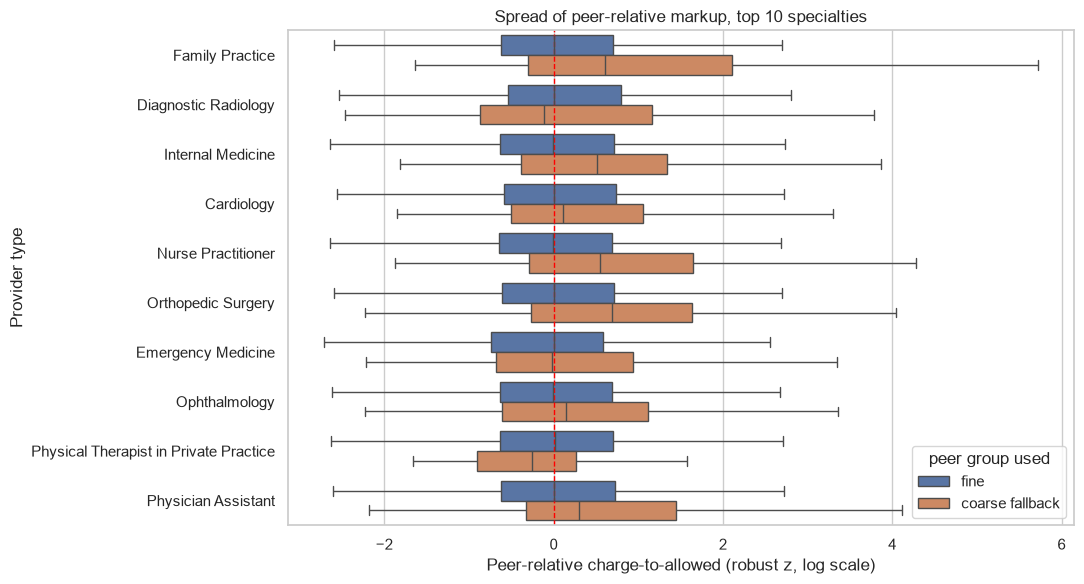

In [20]:
# Spread of the peer-relative markup by specialty, split by which peer level was used
sc_sample = df[scored].sample(min(500_000, int(scored.sum())), random_state=SEED)
top10 = df["Rndrng_Prvdr_Type"].value_counts().head(10).index
sc_sample = sc_sample[sc_sample["Rndrng_Prvdr_Type"].isin(top10)].copy()
sc_sample["Rndrng_Prvdr_Type"] = sc_sample["Rndrng_Prvdr_Type"].astype(str)
sc_sample["peer group used"] = sc_sample["peer_level"].map({1: "fine", 2: "coarse fallback"})

plt.figure(figsize=(11, 6))
sns.boxplot(data=sc_sample, x="chrg_to_alowd_rz", y="Rndrng_Prvdr_Type", hue="peer group used",
            orient="h", showfliers=False)
plt.axvline(0, color="red", ls="--", lw=1)
plt.xlabel("Peer-relative charge-to-allowed (robust z, log scale)")
plt.ylabel("Provider type")
plt.title("Spread of peer-relative markup, top 10 specialties")
savefig("peer_rz_spread_by_specialty")

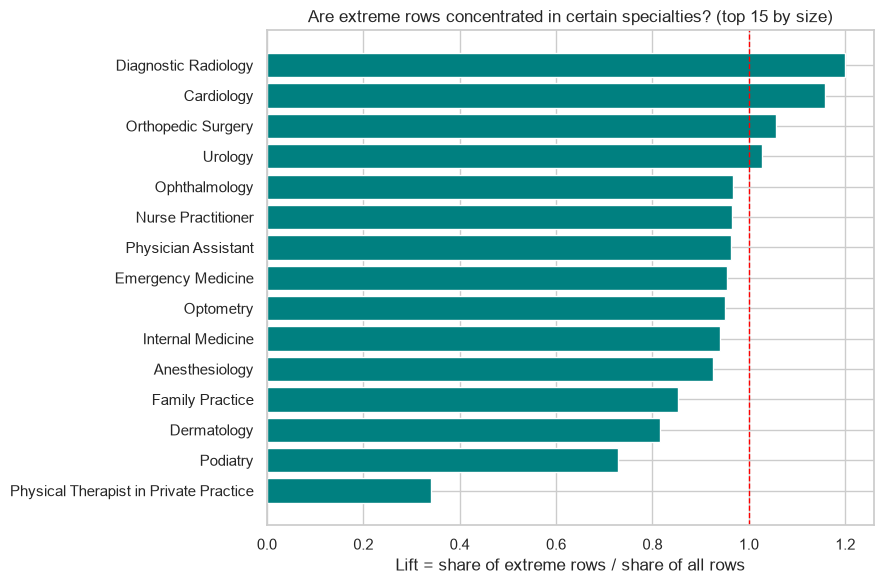

In [21]:
# Concentration: is any specialty over-represented among extreme rows?
flag3 = ext["any |rz| > 3"] & scored
spec = pd.DataFrame({
    "row_share":  df.loc[scored, "Rndrng_Prvdr_Type"].value_counts(normalize=True),
    "flag_share": df.loc[flag3,  "Rndrng_Prvdr_Type"].value_counts(normalize=True),
})
spec = spec[spec["row_share"] > 0]
spec["lift"] = spec["flag_share"] / spec["row_share"]          # 1.0 = flagged in proportion to size
top_spec = spec.nlargest(15, "row_share").sort_values("lift")

plt.figure(figsize=(9, 6))
plt.barh(top_spec.index.astype(str), top_spec["lift"], color="teal")
plt.axvline(1, color="red", ls="--", lw=1)
plt.xlabel("Lift = share of extreme rows / share of all rows")
plt.title("Are extreme rows concentrated in certain specialties? (top 15 by size)")
savefig("extreme_lift_by_specialty")

## 7. Statistical baseline
This is the transparent baseline from the proposal, to be compared against the Isolation Forest later (rank correlation and top-K overlap).

**Score definition**
1. For each row, take the **largest absolute robust z** across the five metrics: "how unusual is the *most* unusual thing about this row, relative to its peers?"
2. Rank that value across all scored rows and rescale to **0–100** (`baseline_score`), matching the 0–100 risk-score scale in the proposal.
3. Flag the **top 1%, 5% and 10%** (`flag_top1/5/10`), the same bands used for top-K profiling.

The score is two-sided (unusually low is also unusual), like Isolation Forest. It measures statistical unusualness only, **not** fraud.

In [22]:
df["baseline_raw"] = df[rz_cols].abs().max(axis=1, skipna=True).astype("float32")
df["baseline_score"] = (df["baseline_raw"].rank(pct=True) * 100).astype("float32")   # unscored rows stay NaN

for k in (1, 5, 10):
    df[f"flag_top{k}"] = df["baseline_score"] >= (100 - k)

print("Flagged rows:", {k: int(df[f"flag_top{k}"].sum()) for k in (1, 5, 10)}, "| scored rows:", int(scored.sum()))
df.loc[scored, "baseline_score"].describe().round(2)

Flagged rows: {1: 97809, 5: 489042, 10: 978084} | scored rows: 9780833


count    9780833.00
mean          50.00
std           28.87
min            0.00
25%           25.00
50%           50.00
75%           75.00
max          100.00
Name: baseline_score, dtype: float64

In [23]:
# Top-K profiling: what distinguishes flagged rows from the rest? (medians, on the original scale)
prof_cols = ["Tot_Srvcs", "Avg_Sbmtd_Chrg", "Avg_Mdcr_Stdzd_Amt", "srvcs_per_bene", "chrg_to_alowd"]
profile = pd.DataFrame(index=prof_cols)
for k in (1, 5, 10):
    flagged = df[f"flag_top{k}"]
    rest = scored & ~flagged
    profile[f"median_top{k}"] = df.loc[flagged, prof_cols].median()
    profile[f"ratio_top{k}_vs_rest"] = df.loc[flagged, prof_cols].median() / df.loc[rest, prof_cols].median()
profile.round(2)

,median_top1,ratio_top1_vs_rest,median_top5,ratio_top5_vs_rest,median_top10,ratio_top10_vs_rest
Tot_Srvcs,43.00,1.00,42.00,0.95,44.00,1.02
Avg_Sbmtd_Chrg,125.00,0.69,175.90,0.98,193.46,1.09
Avg_Mdcr_Stdzd_Amt,31.92,0.60,44.43,0.83,46.76,0.87
srvcs_per_bene,1.10,1.03,1.16,1.08,1.13,1.06
chrg_to_alowd,3.05,1.02,3.12,1.05,3.30,1.12


,pct_flagged_top5,rows
segment,,
drug,6.947218,529363
mileage,1.325189,9659
service,4.892310,9241811


,pct_flagged_top5,rows
Place_Of_Srvc,,
F,4.971906,3464265
O,5.015413,6316568


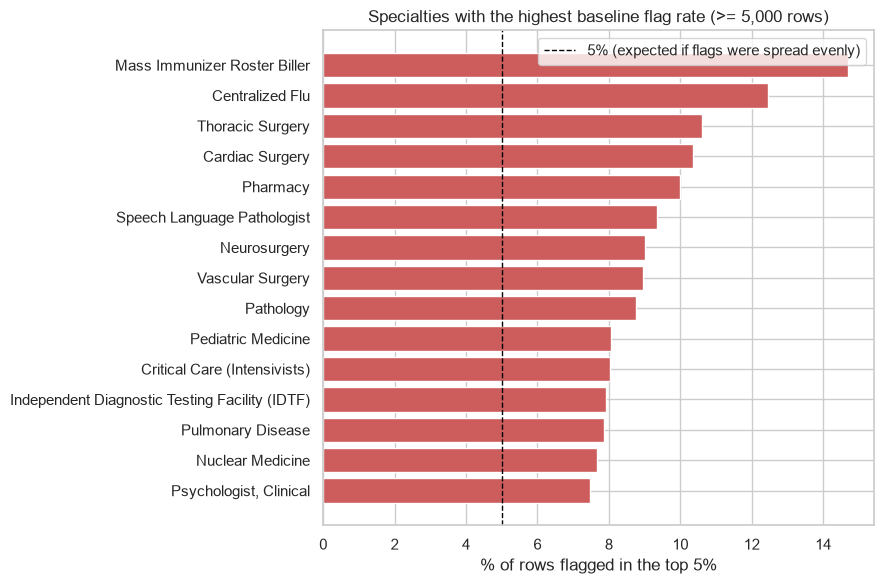

In [27]:
# (top 5% band)
sc = df.loc[scored, ["segment", "Place_Of_Srvc", "Rndrng_Prvdr_Type", "Rndrng_Prvdr_RUCA",
                     "Rndrng_Prvdr_Ent_Cd", "flag_top1", "flag_top5", "flag_top10"]]

def flag_rate(by, k=5):
    r = sc.groupby(by, observed=True)[f"flag_top{k}"].agg(["mean", "size"])
    r["mean"] *= 100
    return r.rename(columns={"mean": f"pct_flagged_top{k}", "size": "rows"})

display(flag_rate("segment"))
display(flag_rate("Place_Of_Srvc"))

spec_rate = (flag_rate("Rndrng_Prvdr_Type").query("rows >= 5000")
             .sort_values("pct_flagged_top5", ascending=False).head(15))
plt.figure(figsize=(9, 6))
plt.barh(spec_rate.index.astype(str)[::-1], spec_rate["pct_flagged_top5"][::-1], color="indianred")
plt.axvline(5, color="black", ls="--", lw=1, label="5% (expected if flags were spread evenly)")
plt.xlabel("% of rows flagged in the top 5%")
plt.title("Specialties with the highest baseline flag rate (>= 5,000 rows)")
plt.legend()
savefig("baseline_flag_rate_by_specialty")

### Ethics check: are rural or small practices over-flagged?
The proposal commits to checking that poorly defined peer groups do not unfairly flag legitimate providers such as rural or low-volume practices. Two views:
1. **Raw flag rate** by RUCA category (rural–urban commuting area) and by individual vs. organization. Under an even spread, each would sit at 5%.
2. **Observed vs. expected:** the expected rate for a RUCA group is what we would see if its rows were flagged at their *specialty's* average rate. A ratio near 1 means any difference is explained by specialty mix, not by location.

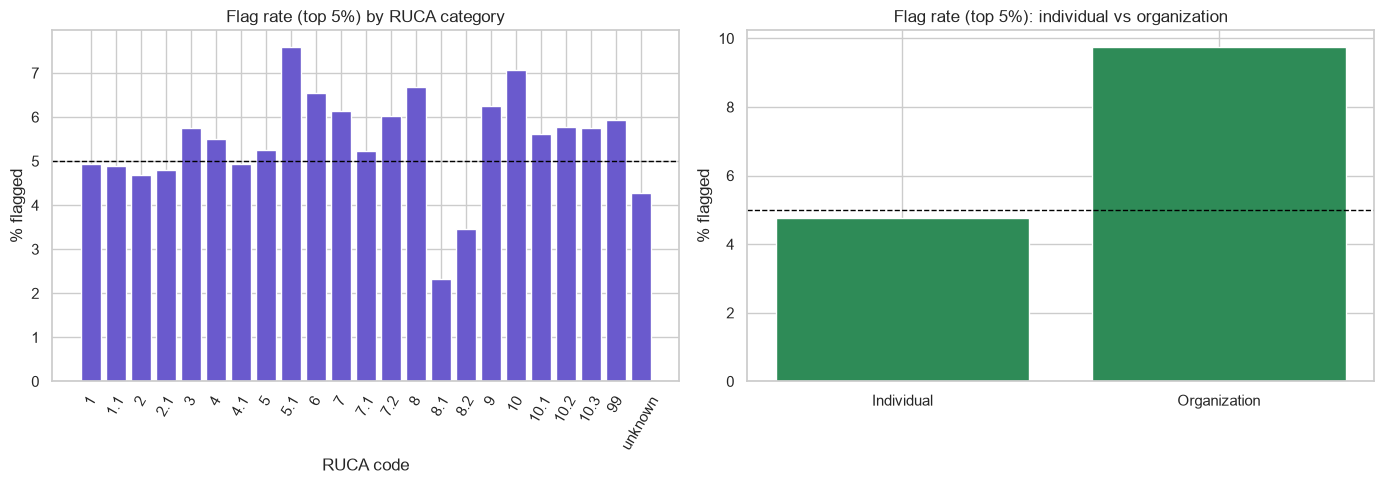

,pct_flagged_top5,rows
Rndrng_Prvdr_RUCA,,
1,4.92,8367221
1.1,4.89,143922
2,4.68,262977
2.1,4.79,3530
3,5.76,11133
4,5.51,599679
4.1,4.94,31210
5,5.26,50332
5.1,7.59,290


,obs_rate,exp_rate,obs_over_exp
Rndrng_Prvdr_RUCA,,,
1,0.049,0.050,0.983
1.1,0.049,0.050,0.971
2,0.047,0.049,0.960
2.1,0.048,0.052,0.914
3,0.058,0.050,1.161
4,0.055,0.050,1.109
4.1,0.049,0.050,0.996
5,0.053,0.049,1.083
5.1,0.076,0.054,1.398


In [25]:
def ruca_key(v):
    n = pd.to_numeric(v, errors="coerce")
    return float("inf") if pd.isna(n) else float(n)          # numeric codes first, 'unknown' last

ruca = flag_rate("Rndrng_Prvdr_RUCA")
ruca = ruca.loc[sorted(ruca.index, key=ruca_key)]
ent = flag_rate("Rndrng_Prvdr_Ent_Cd")
ent.index = ent.index.map({"I": "Individual", "O": "Organization"})

# Observed vs expected given specialty mix
sc = sc.assign(expected_top5=sc.groupby("Rndrng_Prvdr_Type", observed=True)["flag_top5"].transform("mean"))
adj = sc.groupby("Rndrng_Prvdr_RUCA", observed=True).agg(obs_rate=("flag_top5", "mean"),
                                                        exp_rate=("expected_top5", "mean"))
adj["obs_over_exp"] = adj["obs_rate"] / adj["exp_rate"]
adj = adj.loc[sorted(adj.index, key=ruca_key)].round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(ruca.index.astype(str), ruca["pct_flagged_top5"], color="slateblue")
axes[0].axhline(5, color="black", ls="--", lw=1)
axes[0].set_title("Flag rate (top 5%) by RUCA category")
axes[0].set_xlabel("RUCA code"); axes[0].set_ylabel("% flagged")
axes[0].tick_params(axis="x", rotation=60)
axes[1].bar(ent.index, ent["pct_flagged_top5"], color="seagreen")
axes[1].axhline(5, color="black", ls="--", lw=1)
axes[1].set_title("Flag rate (top 5%): individual vs organization")
axes[1].set_ylabel("% flagged")
savefig("ethics_flag_rate_ruca_entity")

display(ruca.round(2))
display(adj)

## 8. Export for the model and dashboard
`peer_features.parquet` is keyed on `row_id`, the same key as Alisa's `ml_table.parquet`. Tyson joins the two for the Isolation Forest; Power BI joins it to the cleaned data for the ranked review queue.

In [26]:
out_cols = (["row_id", "peer_level", "group_n", "group_n_coarse"]
            + [f"{m}_{s}" for m in METRICS for s in ("z", "rz", "pct")]
            + ["baseline_raw", "baseline_score", "flag_top1", "flag_top5", "flag_top10"])
peer_features = df[out_cols].copy()

assert peer_features["row_id"].is_unique
assert len(peer_features) == len(df)

os.makedirs(os.path.dirname(OUT_PARQUET), exist_ok=True)
peer_features.to_parquet(OUT_PARQUET, index=False)

# Data dictionary (paste into the README)
desc = {
    "row_id": "Row key: position after cleaning; same as row_id in the team's ml_table (NPI x HCPCS x place of service)",
    "peer_level": "Peer group used: 1 = fine (Type x POS x HCPCS x segment), 2 = coarse fallback (Type x POS x segment), 0 = unscored",
    "group_n": "Rows in the row's fine peer group",
    "group_n_coarse": "Rows in the row's coarse peer group",
    "baseline_raw": "Largest |robust z| across the five metrics (log1p scale)",
    "baseline_score": "0-100 percentile rank of baseline_raw across scored rows (statistical baseline, NOT a fraud score)",
    "flag_top1": "True if baseline_score is in the top 1%",
    "flag_top5": "True if baseline_score is in the top 5%",
    "flag_top10": "True if baseline_score is in the top 10%",
}
for m in METRICS:
    desc[f"{m}_z"]   = f"z-score of log1p({m}) within the peer group used"
    desc[f"{m}_rz"]  = f"Robust z-score (median / IQR) of log1p({m}) within the peer group used"
    desc[f"{m}_pct"] = f"Percentile rank (0-1) of {m} within the peer group used"

dictionary = pd.DataFrame({"column": out_cols,
                           "dtype": [str(peer_features[c].dtype) for c in out_cols],
                           "description": [desc[c] for c in out_cols]})
dictionary.to_csv(OUT_DICT, index=False)

print(f"Saved {OUT_PARQUET}: {peer_features.shape}")
dictionary

Saved data/processed/peer_features.parquet: (9781161, 24)


,column,dtype,description
0,row_id,int64,Row key: position after cleaning; same as row_...
1,peer_level,int8,Peer group used: 1 = fine (Type x POS x HCPCS ...
2,group_n,int32,Rows in the row's fine peer group
3,group_n_coarse,int32,Rows in the row's coarse peer group
4,Tot_Srvcs_z,float32,z-score of log1p(Tot_Srvcs) within the peer gr...
5,Tot_Srvcs_rz,float32,Robust z-score (median / IQR) of log1p(Tot_Srv...
6,Tot_Srvcs_pct,float32,Percentile rank (0-1) of Tot_Srvcs within the ...
7,Avg_Sbmtd_Chrg_z,float32,z-score of log1p(Avg_Sbmtd_Chrg) within the pe...
8,Avg_Sbmtd_Chrg_rz,float32,Robust z-score (median / IQR) of log1p(Avg_Sbm...
9,Avg_Sbmtd_Chrg_pct,float32,Percentile rank (0-1) of Avg_Sbmtd_Chrg within...
